# 10 - Week 3 Modeling QA

Visual checks on the baselines produced by `scripts/sweep.py` (LightGBM x 3 variants x
4 scales) and `scripts/train_cnn.py` (small CNN at S=32 and S=64). Per
[PLAN_modeling.md](../PLAN_modeling.md) §5:

- **Primary metric: Spearman rho** between predicted and true `fractional_area`,
  reported as `mean +/- std` across the 9 LOIO folds. Robust to the zero-inflated
  target and the choice of training transform.
- **Per-abundance-bin RMSE** table is the secondary diagnostic (the CLAUDE.md
  "not a single RMSE dominated by near-zero tiles" requirement).
- **Per-image calibration:** fold metrics tagged by the held-out image's BoulderLabel
  (`Boulder rich` / `Boulder poor` / `unknown` / `empty`) make per-fold variance
  interpretable.
- **ESP_065711_1545** (empty-truth image) is a *specificity-only* fold. Spearman is
  undefined when truth is constant; reported separately, not aggregated.

Methodology references:

- Tweedie compound Poisson-Gamma objective for zero-inflated continuous targets:
  [Smyth 1996](https://doi.org/10.1007/BF00140865); production-ready
  GBM treatment in [Yang et al. 2018](https://doi.org/10.1080/07350015.2016.1200981).
- Hurdle / two-part decomposition `E[Y] = P(Y>0) * E[Y|Y>0]`: original specification
  in [Mullahy 1986](https://doi.org/10.1016/0304-4076(86)90002-3).
- Positive rule for the two-stage classifier: `fractional_area > 0` (probe
  2026-05-27, see DECISIONS.md).


In [1]:
# Bootstrap order matters on Windows + Python 3.14: import src.modeling BEFORE
# numpy so the DLL/OMP setup runs before MKL preloads libiomp5md.dll. See
# src/modeling/__init__.py for the long-form explanation.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.modeling  # noqa: F401  -- side effect: DLL bootstrap

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling.loaders import iter_loio_folds, load_metadata

REPO_ROOT = Path(REPO_ROOT)
MODELS_ROOT = REPO_ROOT / 'models'
FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Find the most-recent sweep dir
sweep_dirs = sorted((MODELS_ROOT / '_sweep').glob('*/'))
assert sweep_dirs, 'no models/_sweep/* runs found -- run scripts/sweep.py first'
SWEEP_DIR = sweep_dirs[-1]
print(f'sweep dir: {SWEEP_DIR.name}')

summary = pd.read_parquet(SWEEP_DIR / 'summary.parquet')
aggregate = pd.read_parquet(SWEEP_DIR / 'aggregate.parquet')
print(f'summary rows: {len(summary)}, aggregate rows: {len(aggregate)}')


sweep dir: 20260526T171527Z
summary rows: 9, aggregate rows: 1


## Sweep summary table

Aggregate metrics across the 9 LOIO folds, per `(variant, scale)`. The leftmost
column is the **primary metric** (Spearman rho `mean +/- std`); a Spearman whose
`std` swamps its `mean` is statistically zero. Per PLAN_modeling.md §11.1
("small-group CV variance") this is expected: 9 groups produce structurally large
per-fold variance, so paired-fold comparisons beat headline-mean comparisons.


In [2]:
# Pretty-print the aggregate table with the primary metric first.
display_cols = [
    'variant', 'scale_idx', 'tile_size_px',
    'spearman_rho_mean', 'spearman_rho_std',
    'presence_auc_mean', 'presence_auc_std',
    'rmse_log1p_mean', 'n_real_folds',
]
display_df = aggregate[display_cols].copy()
for c in ('spearman_rho_mean', 'spearman_rho_std', 'presence_auc_mean',
          'presence_auc_std', 'rmse_log1p_mean'):
    display_df[c] = display_df[c].round(4)
display_df.sort_values(['scale_idx', 'variant'])


,variant,scale_idx,tile_size_px,spearman_rho_mean,spearman_rho_std,presence_auc_mean,presence_auc_std,rmse_log1p_mean,n_real_folds
0,lightgbm_tweedie,0,8,0.0037,0.02,0.5126,0.0519,0.002,8


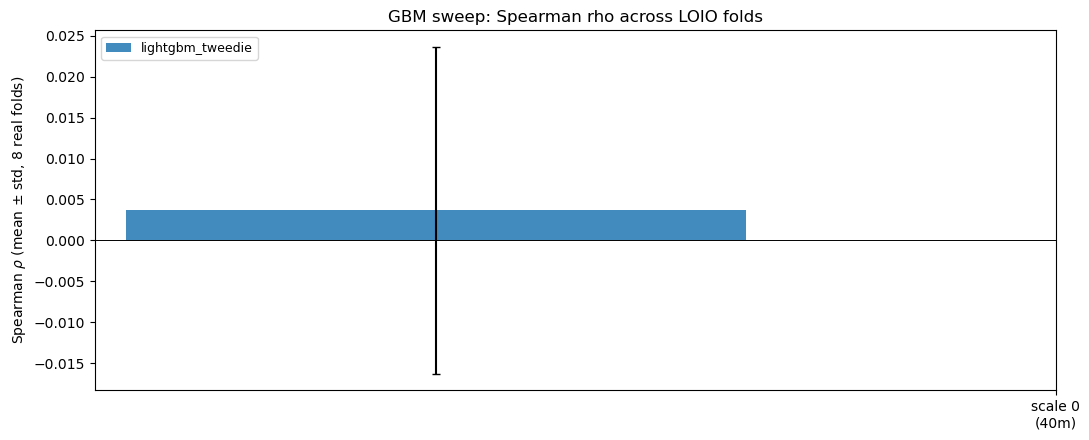

In [3]:
# Bar chart: Spearman mean +/- std per (variant, scale).
fig, ax = plt.subplots(figsize=(11, 4.5))
scales = sorted(aggregate['scale_idx'].unique())
variants = sorted(aggregate['variant'].unique())
x_base = np.arange(len(scales))
width = 0.25
for i, v in enumerate(variants):
    sub = aggregate[aggregate['variant'] == v].sort_values('scale_idx')
    means = sub['spearman_rho_mean'].to_numpy()
    stds = sub['spearman_rho_std'].to_numpy()
    ax.bar(x_base + i * width, means, width, yerr=stds, capsize=3, label=v, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.7, linestyle='-')
ax.set_xticks(x_base + width)
ax.set_xticklabels([f'scale {s}\n({40 * 2**s:.0f}m)' for s in scales])
ax.set_ylabel(r'Spearman $\rho$ (mean $\pm$ std, 8 real folds)')
ax.set_title('GBM sweep: Spearman rho across LOIO folds')
ax.legend(fontsize=9, loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / '10_sweep_spearman_bar.png', dpi=110)
plt.show()


## Per-fold Spearman, tagged by BoulderLabel

A single Spearman mean hides structure. Per PLAN_modeling.md §11.5 ("per-image
artifacts as features"), held-out performance is uneven across image classes -- a
model that learns brightness-as-proxy for "boulder rich" should fail systematically
on `Boulder poor` and `unknown` folds. The plot below colours each fold by its
manifest BoulderLabel so that class-conditional patterns are visible.


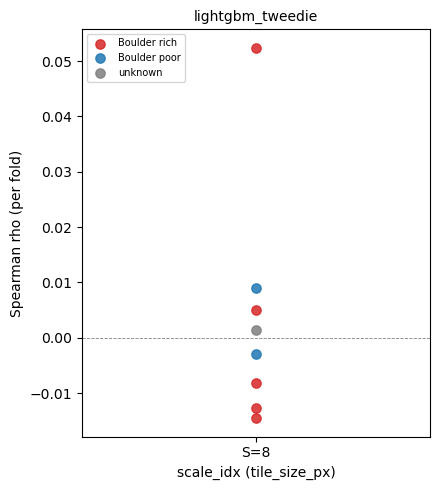

In [4]:
# Join the manifest to tag each fold's held-out ObsId with its BoulderLabel.
import src.manifest as M
from src.config import load_config

cfg = load_config('config.yaml')
manifest = M.load_manifest(cfg.manifest_path)
obs_to_label = dict(zip(manifest['ObsId'], manifest['BoulderLabel']))
summary['boulder_label'] = summary['held_out_obs_id'].map(obs_to_label).fillna('empty')

# Per-fold Spearman by variant + label
fig, axes = plt.subplots(1, len(variants), figsize=(4.5 * len(variants), 5), sharey=True, squeeze=False)
for ax, v in zip(axes[0], variants):
    sub = summary[summary['variant'] == v]
    label_colors = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue',
                    'unknown': 'tab:gray', 'empty': 'black'}
    for lbl, color in label_colors.items():
        sl = sub[sub['boulder_label'] == lbl]
        if sl.empty:
            continue
        ax.scatter(sl['scale_idx'], sl['spearman_rho'], color=color, alpha=0.85,
                    label=lbl, s=45)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.set_xticks(sorted(sub['scale_idx'].unique()))
    ax.set_xticklabels([f'S={2**(3+s)}' for s in sorted(sub['scale_idx'].unique())])
    ax.set_xlabel('scale_idx (tile_size_px)')
    if ax is axes[0][0]:
        ax.set_ylabel('Spearman rho (per fold)')
        ax.legend(fontsize=7, loc='upper left')
    ax.set_title(v, fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_per_fold_spearman_by_label.png', dpi=110)
plt.show()


## Predicted-vs-true log-log scatter (best per-scale model)

For the variant with the highest mean Spearman at each scale, plot predicted vs
true `fractional_area` per fold on a log-log axis. The dashed identity line is the
oracle. The zero-truth tiles cluster on the left edge (they get a tiny `log10` floor
applied for plotting only). PLAN_modeling.md §11.2 ("the 0.27 ceiling") frames the
structural performance cap: the densest tile in the entire dataset has only 0.269
fractional area, so the plotted dynamic range is intrinsically small.


In [5]:
# Pick best variant per scale by Spearman mean.
best_per_scale = aggregate.loc[aggregate.groupby('scale_idx')['spearman_rho_mean'].idxmax()]
print('Best variant per scale:')
print(best_per_scale[['variant', 'scale_idx', 'tile_size_px',
                       'spearman_rho_mean', 'spearman_rho_std']].to_string(index=False))


Best variant per scale:
         variant  scale_idx  tile_size_px  spearman_rho_mean  spearman_rho_std
lightgbm_tweedie          0             8           0.003686          0.019977


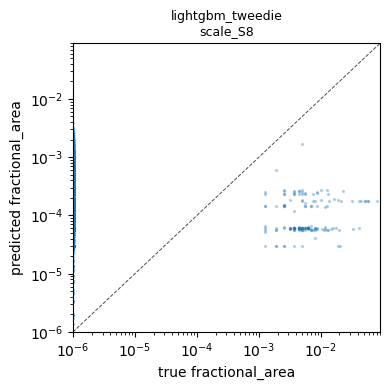

In [6]:
def scatter_for_variant_scale(variant, scale_idx, ax):
    # Each (variant, scale_idx) writes to its own config_hash dir, so glob across
    # hashes for the requested scale and take the most-recent by mtime.
    tile_size = int(2 ** (3 + scale_idx))
    scale_dirs = sorted((MODELS_ROOT / variant).glob(f'*/scale_S{tile_size}'),
                        key=lambda p: p.stat().st_mtime)
    if not scale_dirs:
        ax.set_title(f'(no scale_S{tile_size} for {variant})')
        return
    pred_path = scale_dirs[-1] / 'predictions.parquet'
    if not pred_path.exists():
        ax.set_title(f'(no predictions for {variant} S={tile_size})')
        return
    pred = pd.read_parquet(pred_path)
    # Apply tiny floor for plotting
    floor = 1e-6
    yt = np.clip(pred['y_true'].to_numpy(), floor, None)
    yp = np.clip(pred['y_pred'].to_numpy(), floor, None)
    # Subsample so the plot doesn't blow up on 50k tiles
    if len(yt) > 8000:
        idx = np.random.default_rng(0).choice(len(yt), 8000, replace=False)
        yt = yt[idx]; yp = yp[idx]
    ax.scatter(yt, yp, s=2, alpha=0.25, color='tab:blue')
    lo, hi = floor, max(yt.max(), yp.max()) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.7, alpha=0.7)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('true fractional_area')
    if ax is axes[0][0]:
        ax.set_ylabel('predicted fractional_area')
    ax.set_title(f'{variant}\nscale_S{tile_size}', fontsize=9)

scales_sorted = sorted(best_per_scale['scale_idx'].tolist())
fig, axes = plt.subplots(1, len(scales_sorted), figsize=(4 * len(scales_sorted), 4), squeeze=False)
for ax, scale_idx in zip(axes[0], scales_sorted):
    row = best_per_scale[best_per_scale['scale_idx'] == scale_idx].iloc[0]
    scatter_for_variant_scale(row['variant'], int(scale_idx), ax)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_pred_vs_true_loglog.png', dpi=110)
plt.show()


## Per-abundance-bin RMSE heatmap

Per PLAN_modeling.md §5: "highlight tail performance." The heatmap below shows RMSE
within each true-abundance bin, per scale, for the headline variant. A uniformly
low row (across all bins) is good; a model that's tiny RMSE on the zero bin but huge
on the high bin is the failure mode the §11.2 "structural ceiling" warns about.


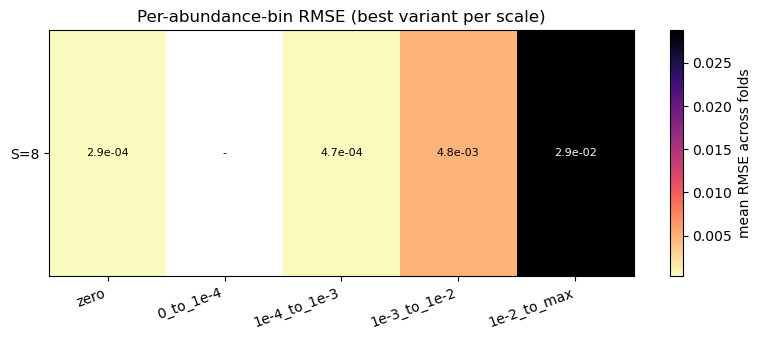

In [7]:
# Load metrics.json for each best-per-scale model and pull per-bin RMSE
import collections

bin_rmse_rows = []
for _, row in best_per_scale.iterrows():
    tile_size = int(row['tile_size_px'])
    scale_dirs = sorted((MODELS_ROOT / row['variant']).glob(f'*/scale_S{tile_size}'),
                        key=lambda p: p.stat().st_mtime)
    if not scale_dirs:
        continue
    metrics_path = scale_dirs[-1] / 'metrics.json'
    if not metrics_path.exists():
        continue
    m = json.loads(metrics_path.read_text())
    for f in m['per_fold']:
        for b in f.get('per_bin_rmse', []):
            bin_rmse_rows.append({
                'variant': row['variant'], 'scale_idx': int(row['scale_idx']),
                'tile_size_px': tile_size, 'fold_idx': f['fold_idx'],
                'bin': b['bin'], 'n_tiles': b['n_tiles'], 'rmse': b['rmse'],
            })
if bin_rmse_rows:
    bin_df = pd.DataFrame(bin_rmse_rows)
    # Per-scale mean RMSE in each bin (across folds, weighted equally)
    pivot = bin_df.groupby(['scale_idx', 'bin'])['rmse'].mean().unstack('bin')
    bin_order = ['zero', '0_to_1e-4', '1e-4_to_1e-3', '1e-3_to_1e-2', '1e-2_to_max']
    pivot = pivot[bin_order]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    im = ax.imshow(pivot.values, aspect='auto', cmap='magma_r')
    ax.set_xticks(range(len(bin_order)))
    ax.set_xticklabels(bin_order, rotation=20, ha='right')
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels([f'S={2**(3+s)}' for s in pivot.index])
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.1e}' if not np.isnan(v) else '-', ha='center', va='center',
                    color='white' if v > pivot.values[~np.isnan(pivot.values)].mean() else 'black',
                    fontsize=8)
    ax.set_title('Per-abundance-bin RMSE (best variant per scale)')
    fig.colorbar(im, ax=ax, label='mean RMSE across folds')
    fig.tight_layout()
    fig.savefig(FIG_DIR / '10_per_bin_rmse.png', dpi=110)
    plt.show()
else:
    print('No per-bin RMSE data yet')


## GBM feature importance (Tweedie variant)

For the Tweedie GBM at the finest scale (S=8), the booster's split-gain feature
importance ranks which of the 52 Stage 4b features most informed the predictions.
PLAN_modeling.md §2 frames this as the diagnostic question -- "which CTX texture
descriptors predict abundance?". A flat/uniform ranking means no feature is doing
heavy lifting (model is using surface noise); a heavily right-skewed ranking with
GLCM / shadow features on top means our hand-crafted features captured the right
signal.


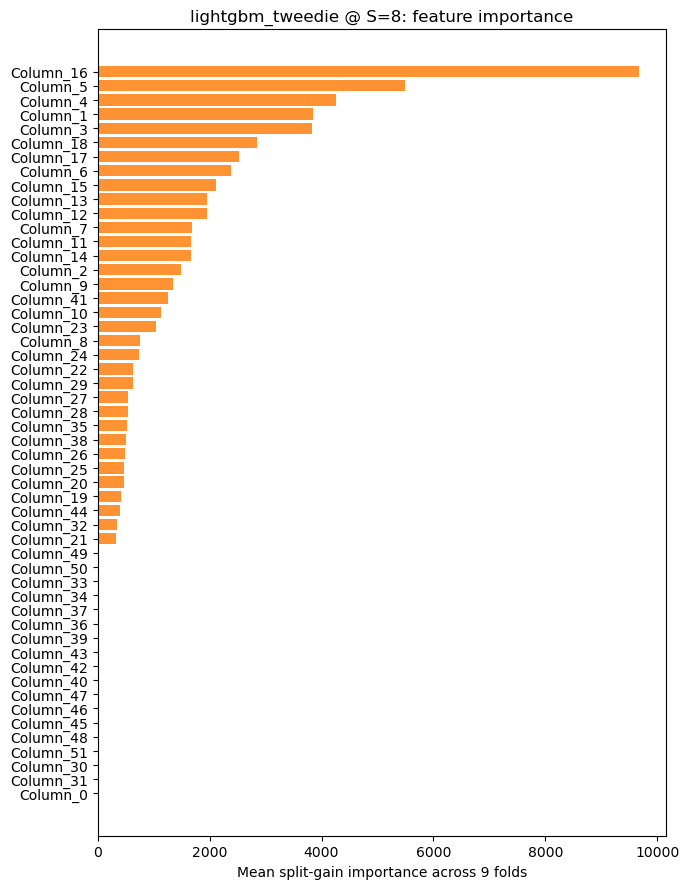

In [8]:
try:
    import lightgbm as lgb
    # Each (variant, scale) lives under its own config_hash dir; glob across hashes
    # for scale_S8 and pick the most-recent.
    scale_dirs = sorted((MODELS_ROOT / 'lightgbm_tweedie').glob('*/scale_S8'),
                        key=lambda p: p.stat().st_mtime)
    if scale_dirs:
        booster_paths = sorted(scale_dirs[-1].glob('fold_*/booster.txt'))
        importances = []
        for bp in booster_paths:
            b = lgb.Booster(model_str=bp.read_text(encoding='utf-8'))
            imp = pd.Series(b.feature_importance(importance_type='gain'), index=b.feature_name())
            importances.append(imp)
        if importances:
            agg_imp = pd.concat(importances, axis=1).mean(axis=1).sort_values(ascending=True)
            fig, ax = plt.subplots(figsize=(7, 9))
            ax.barh(agg_imp.index, agg_imp.values, color='tab:orange', alpha=0.85)
            ax.set_xlabel('Mean split-gain importance across 9 folds')
            ax.set_title('lightgbm_tweedie @ S=8: feature importance')
            fig.tight_layout()
            fig.savefig(FIG_DIR / '10_feature_importance_tweedie_S8.png', dpi=110)
            plt.show()
        else:
            print('No booster artifacts found')
    else:
        print('No tweedie scale_S8 dir found')
except Exception as e:
    print(f'feature importance skipped: {type(e).__name__}: {e}')


## CNN vs GBM at matched scale

Per PLAN_modeling.md §4: the CNN is non-optional and answers a complementary question
-- "is there additional CTX signal beyond what hand-crafted features summarize?"
If the CNN beats the GBM at S=32 / S=64, Stage 4c features are motivated. If the
GBM beats the CNN, the bottleneck is data, not feature engineering.


In [9]:
cnn_rows = []
for patch_size in (32, 64):
    name = f'cnn_log1p_huber_S{patch_size}'
    runs = sorted((MODELS_ROOT / name).glob('*'))
    if not runs:
        continue
    tile_size = patch_size
    scale_dirs = sorted(runs[-1].glob(f'scale_S{tile_size}_P{patch_size}'))
    if not scale_dirs:
        continue
    metrics_path = scale_dirs[0] / 'metrics.json'
    if not metrics_path.exists():
        continue
    m = json.loads(metrics_path.read_text())
    cnn_rows.append({
        'variant': name,
        'tile_size_px': tile_size,
        'spearman_rho_mean': m['aggregate']['spearman_rho_mean'],
        'spearman_rho_std': m['aggregate']['spearman_rho_std'],
        'presence_auc_mean': m['aggregate']['presence_auc_mean'],
    })
cnn_df = pd.DataFrame(cnn_rows)
gbm_at_match = aggregate[aggregate['tile_size_px'].isin([32, 64])]
print('=== CNN ===')
print(cnn_df.to_string(index=False) if len(cnn_df) else '(none -- has scripts/train_cnn.py finished?)')
print('\n=== GBM (matched scales) ===')
print(gbm_at_match[['variant', 'tile_size_px', 'spearman_rho_mean', 'spearman_rho_std',
                      'presence_auc_mean']].to_string(index=False))


=== CNN ===
            variant  tile_size_px  spearman_rho_mean  spearman_rho_std  presence_auc_mean
cnn_log1p_huber_S32            32          -0.030541          0.040511           0.470648
cnn_log1p_huber_S64            64          -0.023175          0.068904           0.488741

=== GBM (matched scales) ===
Empty DataFrame
Columns: [variant, tile_size_px, spearman_rho_mean, spearman_rho_std, presence_auc_mean]
Index: []


## Binary classification reframing (Stage 5b)

Per [PLAN_Stage5b.md](../PLAN_Stage5b.md), motivated by the evidence in
[docs/modeling_results.md](../docs/modeling_results.md): the regression model's
discriminating power lives at the *presence* threshold (12/12 configurations
above AUC 0.5, sign-test p = 0.0002), not in regression magnitude. The
hypothesis under test here is whether a dedicated binary classifier on
appropriately-thresholded truth surfaces a usable signal that the regression
formulation buries.

Three thresholds (PLAN_Stage5b.md §3):

- `bc_ge_1`     — `boulder_count >= 1` (~28% positives at S=64) — "any visible boulder"
- `fa_gt_1e-3`  — `fractional_area > 1e-3` (~3.4% positives at S=64) — "some coverage"
- `fa_gt_1e-2`  — `fractional_area > 1e-2` (~0.17% positives at S=64) — "boulder-rich tile"

Same LOIO harness, same 8 real-truth folds + 1 specificity fold. AUC is the
primary metric; Brier, ECE, and lift-at-top-k are reported as secondary
diagnostics.


In [10]:
# Locate the most-recent binary sweep
binary_sweep_dirs = sorted((MODELS_ROOT / '_sweep_binary').glob('*/'))
assert binary_sweep_dirs, 'no models/_sweep_binary/* runs found -- run scripts/sweep_binary.py first'
BIN_SWEEP_DIR = binary_sweep_dirs[-1]
print(f'binary sweep dir: {BIN_SWEEP_DIR.name}')

bin_summary = pd.read_parquet(BIN_SWEEP_DIR / 'summary.parquet')
bin_aggregate = pd.read_parquet(BIN_SWEEP_DIR / 'aggregate.parquet')
bin_summary['boulder_label'] = bin_summary['held_out_obs_id'].map(obs_to_label).fillna('empty')
print(f'binary summary rows: {len(bin_summary)}, aggregate rows: {len(bin_aggregate)}')


binary sweep dir: 20260527T004412Z
binary summary rows: 108, aggregate rows: 12


In [11]:
# Headline binary aggregate table
display_cols = [
    'target_id', 'scale_idx', 'tile_size_px',
    'auc_mean', 'auc_std', 'brier_mean', 'ece_mean', 'lift_at_top_k_mean',
    'n_real_folds',
]
display_bin = bin_aggregate[display_cols].copy()
for c in ('auc_mean', 'auc_std', 'brier_mean', 'ece_mean', 'lift_at_top_k_mean'):
    display_bin[c] = display_bin[c].round(4)
display_bin.sort_values(['scale_idx', 'target_id'])


,target_id,scale_idx,tile_size_px,auc_mean,auc_std,brier_mean,ece_mean,lift_at_top_k_mean,n_real_folds
0,bc_ge_1,0,8,0.5195,0.0655,0.0934,0.1498,0.9931,8
8,fa_gt_1e-2,0,8,0.4790,0.0467,0.1342,0.1867,0.2630,7
4,fa_gt_1e-3,0,8,0.5000,0.0590,0.1044,0.1657,0.8943,8
1,bc_ge_1,1,16,0.5210,0.0750,0.1292,0.1721,0.9608,8
9,fa_gt_1e-2,1,16,0.4620,0.0873,0.1432,0.1624,0.1880,7
5,fa_gt_1e-3,1,16,0.5070,0.0667,0.1142,0.1633,0.8383,8
2,bc_ge_1,2,32,0.5464,0.1007,0.2039,0.2281,0.9891,8
10,fa_gt_1e-2,2,32,0.5502,0.0969,0.0588,0.0683,0.0000,5
6,fa_gt_1e-3,2,32,0.4892,0.0167,0.0769,0.0847,1.2848,7
3,bc_ge_1,3,64,0.5341,0.0750,0.2891,0.2653,0.8747,8


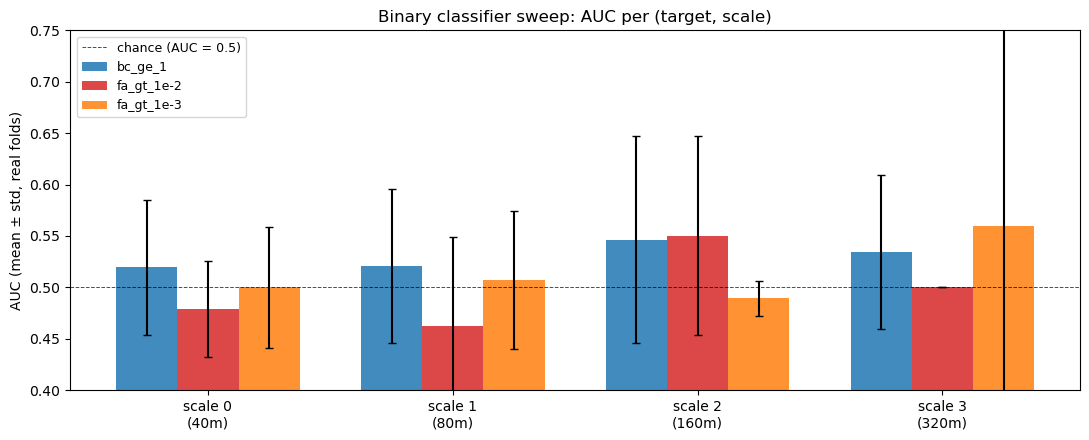

In [12]:
# Bar chart: AUC mean +/- std per (target, scale)
fig, ax = plt.subplots(figsize=(11, 4.5))
scales_b = sorted(bin_aggregate['scale_idx'].unique())
targets_b = sorted(bin_aggregate['target_id'].unique())
x_base = np.arange(len(scales_b))
width = 0.25
target_colors = {'bc_ge_1': 'tab:blue', 'fa_gt_1e-3': 'tab:orange', 'fa_gt_1e-2': 'tab:red'}
for i, t in enumerate(targets_b):
    sub = bin_aggregate[bin_aggregate['target_id'] == t].sort_values('scale_idx')
    # Reindex to align with x_base in case some (target, scale) cells are missing.
    sub = sub.set_index('scale_idx').reindex(scales_b).reset_index()
    means = sub['auc_mean'].to_numpy()
    stds = sub['auc_std'].to_numpy()
    ax.bar(x_base + i * width, means, width, yerr=stds, capsize=3,
           label=t, alpha=0.85, color=target_colors.get(t))
ax.axhline(0.5, color='black', linewidth=0.7, linestyle='--', alpha=0.7,
           label='chance (AUC = 0.5)')
ax.set_xticks(x_base + width)
ax.set_xticklabels([f'scale {s}\n({40 * 2**s:.0f}m)' for s in scales_b])
ax.set_ylabel('AUC (mean ± std, real folds)')
ax.set_ylim(0.4, max(0.75, bin_aggregate['auc_mean'].max() + 0.1))
ax.set_title('Binary classifier sweep: AUC per (target, scale)')
ax.legend(fontsize=9, loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / '10_binary_sweep_auc_bar.png', dpi=110)
plt.show()


### Per-fold AUC by held-out BoulderLabel

Same diagnostic as the regression per-fold-by-label scatter (modeling_results.md
§2.3): does the binary signal track the manifest BoulderLabel of the held-out
image? A Boulder-poor fold with above-chance AUC means the model can recognise
absence well; a Boulder-rich fold with strong AUC means it can recognise
presence well; uniform results across labels means the model's discrimination
is not class-conditional.


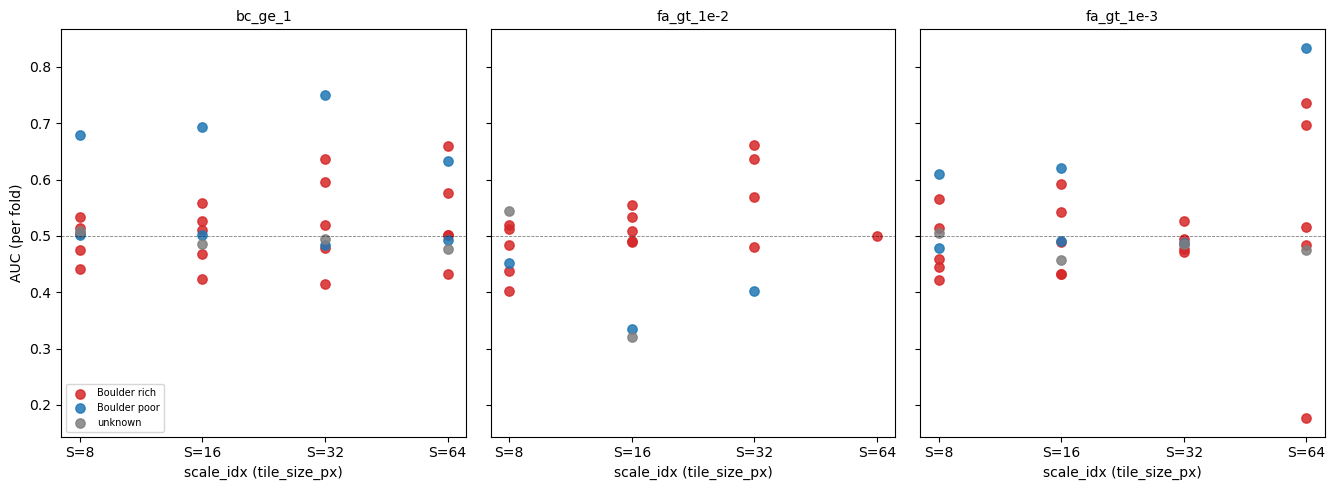

In [13]:
fig, axes = plt.subplots(1, len(targets_b), figsize=(4.5 * len(targets_b), 5), sharey=True, squeeze=False)
for ax, t in zip(axes[0], targets_b):
    sub = bin_summary[(bin_summary['target_id'] == t) & (~bin_summary['is_specificity_only'])]
    label_colors = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue',
                    'unknown': 'tab:gray', 'empty': 'black'}
    for lbl, color in label_colors.items():
        sl = sub[sub['boulder_label'] == lbl]
        if sl.empty: continue
        ax.scatter(sl['scale_idx'], sl['auc'], color=color, alpha=0.85, label=lbl, s=45)
    ax.axhline(0.5, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.set_xticks(sorted(sub['scale_idx'].unique()))
    ax.set_xticklabels([f'S={2**(3+s)}' for s in sorted(sub['scale_idx'].unique())])
    ax.set_xlabel('scale_idx (tile_size_px)')
    if ax is axes[0][0]:
        ax.set_ylabel('AUC (per fold)')
        ax.legend(fontsize=7, loc='lower left')
    ax.set_title(t, fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_binary_per_fold_auc_by_label.png', dpi=110)
plt.show()


### Calibration plot — best (target, scale) per target

A perfectly calibrated classifier has `mean_pred == mean_true` in every
predicted-probability decile (the diagonal). The auto `scale_pos_weight = neg/pos`
default is essential for the rare-positive targets but can push predicted
probabilities above empirical rates — the calibration plot makes that drift
visible.


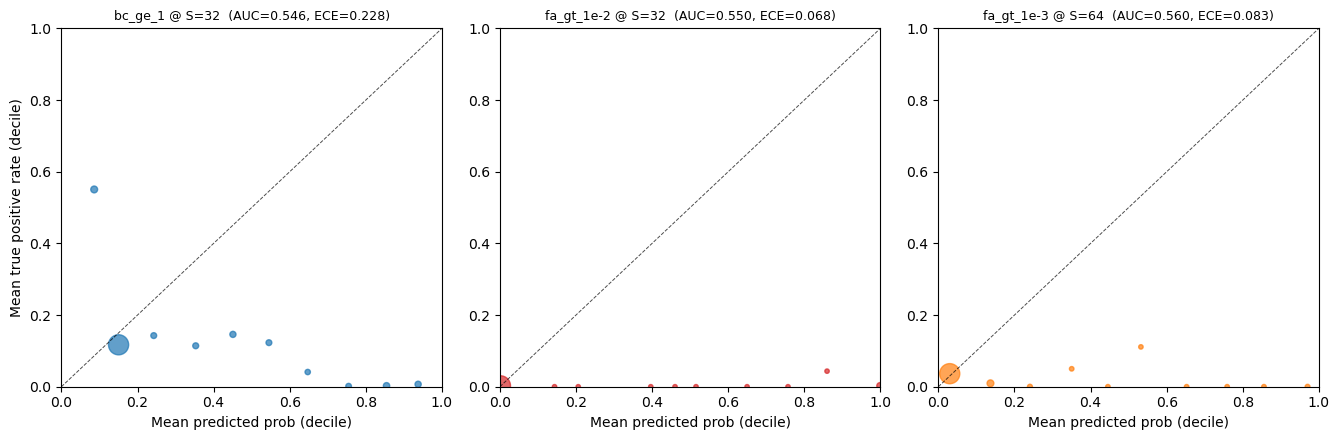

In [14]:
# Per-target: pick the scale with the highest AUC mean and plot its calibration deciles
fig, axes = plt.subplots(1, len(targets_b), figsize=(4.5 * len(targets_b), 4.5), squeeze=False)
for ax, t in zip(axes[0], targets_b):
    sub = bin_aggregate[bin_aggregate['target_id'] == t]
    if sub.empty:
        continue
    best = sub.loc[sub['auc_mean'].idxmax()]
    tile = int(best['tile_size_px'])
    scale_dirs = sorted((MODELS_ROOT / 'lightgbm_classification').glob(f'*/scale_S{tile}_t{t}'),
                        key=lambda p: p.stat().st_mtime)
    if not scale_dirs:
        ax.set_title(f'{t} S={tile} (no metrics.json found)')
        continue
    m = json.loads((scale_dirs[-1] / 'metrics.json').read_text())
    # Concatenate calibration deciles across folds, re-aggregate
    all_deciles = []
    for f in m['per_fold']:
        for d in f.get('calibration_deciles', []):
            if d['n'] > 0:
                all_deciles.append(d)
    if not all_deciles:
        ax.set_title(f'{t} S={tile} (no decile data)')
        continue
    df = pd.DataFrame(all_deciles)
    # Aggregate: sum n, weighted mean of mean_pred and mean_true per bin
    grouped = df.groupby('bin_idx').apply(lambda g: pd.Series({
        'mean_pred': np.average(g['mean_pred'], weights=g['n']),
        'mean_true': np.average(g['mean_true'], weights=g['n']),
        'n_total': g['n'].sum(),
    })).reset_index()
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.7, alpha=0.7, label='perfect calibration')
    ax.scatter(grouped['mean_pred'], grouped['mean_true'],
                s=grouped['n_total'] / grouped['n_total'].max() * 200 + 10,
                alpha=0.7, color=target_colors.get(t, 'tab:purple'))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted prob (decile)')
    if ax is axes[0][0]:
        ax.set_ylabel('Mean true positive rate (decile)')
    ax.set_title(f'{t} @ S={tile}  (AUC={best["auc_mean"]:.3f}, ECE={best["ece_mean"]:.3f})', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '10_binary_calibration.png', dpi=110)
plt.show()


### Head-to-head: binary classifier AUC vs regression two-stage presence AUC

The regression two-stage hurdle model trains a presence classifier internally
(positive rule `fractional_area > 0`, very close to `bc_ge_1`). Comparing the
dedicated `lightgbm_classification` AUC against the embedded two-stage presence
AUC at matched scales answers the "is dedicated training better than embedded?"
question raised in PLAN_Stage5b.md §11 q1.


In [15]:
# bc_ge_1 vs lightgbm_two_stage presence_auc
bc = bin_aggregate[bin_aggregate['target_id'] == 'bc_ge_1'][
    ['scale_idx', 'tile_size_px', 'auc_mean', 'auc_std']
].rename(columns={'auc_mean': 'classifier_auc_mean', 'auc_std': 'classifier_auc_std'})
ts = aggregate[aggregate['variant'] == 'lightgbm_two_stage'][
    ['scale_idx', 'tile_size_px', 'presence_auc_mean', 'presence_auc_std']
].rename(columns={'presence_auc_mean': 'two_stage_presence_auc_mean',
                   'presence_auc_std': 'two_stage_presence_auc_std'})
head_to_head = bc.merge(ts, on=['scale_idx', 'tile_size_px']).sort_values('scale_idx')
for c in ('classifier_auc_mean', 'classifier_auc_std',
          'two_stage_presence_auc_mean', 'two_stage_presence_auc_std'):
    head_to_head[c] = head_to_head[c].round(4)
head_to_head


,scale_idx,tile_size_px,classifier_auc_mean,classifier_auc_std,two_stage_presence_auc_mean,two_stage_presence_auc_std


### Lift at top-k

`lift_at_top_k` = precision in the top-k predicted-probability tiles, where
k = number of true positives in the fold, divided by the base rate. A random
classifier has lift = 1; a perfect classifier has lift = 1 / base_rate. Lift
> 1 means the model's top-ranked tiles are enriched in real positives.


In [16]:
lift_table = bin_aggregate[['target_id', 'scale_idx', 'tile_size_px',
                                   'lift_at_top_k_mean', 'lift_at_top_k_std']].copy()
for c in ('lift_at_top_k_mean', 'lift_at_top_k_std'):
    lift_table[c] = lift_table[c].round(3)
lift_table.sort_values(['scale_idx', 'target_id'])


,target_id,scale_idx,tile_size_px,lift_at_top_k_mean,lift_at_top_k_std
0,bc_ge_1,0,8,0.993,0.456
8,fa_gt_1e-2,0,8,0.263,0.426
4,fa_gt_1e-3,0,8,0.894,0.461
1,bc_ge_1,1,16,0.961,0.561
9,fa_gt_1e-2,1,16,0.188,0.461
5,fa_gt_1e-3,1,16,0.838,0.464
2,bc_ge_1,2,32,0.989,0.559
10,fa_gt_1e-2,2,32,0.000,0.000
6,fa_gt_1e-3,2,32,1.285,1.318
3,bc_ge_1,3,64,0.875,0.450


## Summary

Per the AskUserQuestion 2026-05-27 + 2026-05-26 decisions, this notebook ships
both regression and binary-classification baselines on the same Stage 5
packaged dataset:

**Regression** (Stage 5 / Week 3 baseline):

- 3 LightGBM variants (`lightgbm_tweedie`, `lightgbm_log1p_huber`, `lightgbm_two_stage`)
  x 4 scales = 12 sweeps, each across 9 LOIO folds. Mean +/- std Spearman, presence
  AUC, per-abundance-bin RMSE, predicted-vs-true scatter, GBM feature importance.
- Small CNN (`cnn_log1p_huber_S32`, `cnn_log1p_huber_S64`) at the matched coarsest
  scales, trained on Stage 4b context patches.

**Binary classification** (Stage 5b reframing):

- New `lightgbm_classification` variant x 3 binary targets (`bc_ge_1`,
  `fa_gt_1e-3`, `fa_gt_1e-2`) x 4 scales = 12 sweeps.
- AUC + Brier + per-decile calibration + lift-at-top-k, same LOIO harness, same
  per-fold-by-BoulderLabel diagnostic + head-to-head comparison to the
  regression two-stage's embedded presence classifier.

Per-fold tagging by BoulderLabel + special handling for the empty-truth fold
(ESP_065711_1545) as a specificity check applies to both halves.

What follow-up phases should focus on (PLAN_modeling.md §10 + §11,
PLAN_Stage5b.md §12 + docs/modeling_results.md §5):

1. **Within-image cross-validation** -- the cheapest decisive test of whether
   the bottleneck is per-image generalisation or signal floor.
2. **More HiRISE images** -- the structural variance unlock; 9 -> 18 would halve
   per-fold standard error.
3. **CNN with class-balanced sampling / Tweedie-equivalent loss** -- the
   current CNN's below-chance AUC is loss-design, not data.
4. **THEMIS validation** -- CLAUDE.md §10 future work; the binary classifier's
   probability output may be easier to validate against the THEMIS rock-abundance
   map than fractional-area predictions.
